SCALCS is designed to calculate and display variuos properties of ion channels as described in several papers (see references in SCALCS main page).

##### Some general settings

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
from samples import samples
from scalcs import cjumps

##### Define a mechanism

First, all calculations here require to specify a mechanism and give values for the rate constants (i.e. to define the $Q$ matrix).  Different ways to do that are shown elsehere (... when ready ...).  
In this notebook a mechanism used as the numerical example by Colquhoun & Hawkes 1982 is loaded from DCPYPS. 

In [3]:
demomec = samples.CH82()
print(demomec)


class dcpyps.Mechanism
Values of unit rates [1/sec]:
0	From AR  	to AR*    	beta1   	15.0
1	From A2R  	to A2R*    	beta2   	15000.0
2	From AR*  	to AR    	alpha1   	3000.0
3	From A2R*  	to A2R    	alpha2   	500.0
4	From AR  	to R    	k(-1)   	2000.0
5	From A2R  	to AR    	2k(-2)   	4000.0
6	From R  	to AR    	2k(+1)   	100000000.0
7	From AR*  	to A2R*    	k*(+2)   	500000000.0
8	From AR  	to A2R    	k(+2)   	500000000.0
9	From A2R*  	to AR*    	2k*(-2)   	0.66667

Conductance of state AR* (pS)  =      60

Conductance of state A2R* (pS)  =      60

Number of open states = 2
Number of short-lived shut states (within burst) = 2
Number of long-lived shut states (between bursts) = 1
Number of desensitised states = 0

Number of cycles = 1
Cycle 0 is formed of states: A2R*  AR*  AR  A2R  
	forward product = 1.500007500e+16
	backward product = 1.500000000e+16


##### Macroscopic response to agonist concentration pulse

Define a realistic profile of concentration pulse:

In [7]:
# Here one can tweak the parameters of the jump.
step_size = 8e-6 # The sample step. All time parameters in seconds
pulse_centre = 10e-3
rise_time = 250e-6 # 10-90% rise time for error functions
pulse_width = 10e-3
record_length = 50e-3
peak_conc = 10e-6    # in M
baseline_conc = 0.0
cjargs = (peak_conc, baseline_conc, pulse_centre, pulse_width,
            rise_time, rise_time)

GREEN- concentration pulse profile
BLUE- open probability profile


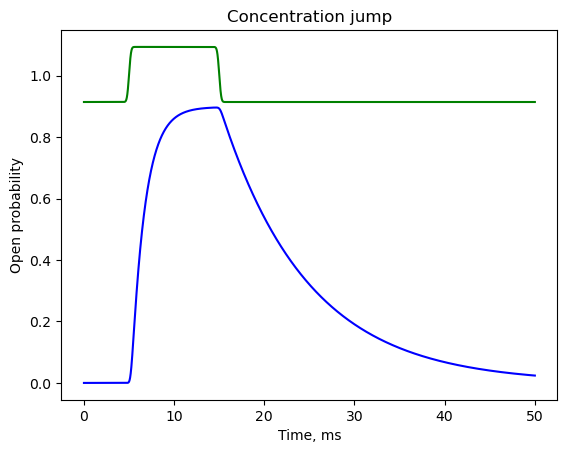

In [8]:
t, c, Popen, P  = cjumps.solve_jump(demomec, record_length, step_size,
        cjumps.pulse_erf, cjargs)
maxP = max(Popen)
maxC = max(c)
c1 = (c / maxC) * 0.2 * maxP + 1.02 * maxP

plt.plot(t * 1000, Popen,'b-', t * 1000, c1, 'g-')
plt.ylabel('Open probability')
plt.xlabel('Time, ms')
plt.title('Concentration jump')
print('GREEN- concentration pulse profile\nBLUE- open probability profile')

Calculate properties of a macroscopic response to an ideal square pulse:

In [9]:
print (cjumps.printout(demomec, peak_conc, pulse_width))


*******************************************
CONCENTRATION JUMPS

Equilibrium occupancies before t=0, at concentration = 0.0:
p00(1) = 0
p00(2) = 0
p00(3) = 0
p00(4) = 4.2352e-22
p00(5) = 1

Equilibrium occupancies at maximum concentration = 0.01 mM:
pinf(1) = 0.00011975
pinf(2) = 0.8981
pinf(3) = 0.023949
pinf(4) = 0.029937
pinf(5) = 0.047898

Occupancies at the end of 10 ms pulse:
pt(1) = 0.00012
pt(2) = 0.89679
pt(3) = 0.024133
pt(4) = 0.029951
pt(5) = 0.049008

ON-RELAXATION for ideal step:
Time course for current

Comp	Eigen		Tau (ms)
1	-20828		0.048012	
2	-8017.9		0.12472	
3	-6001.6		0.16662	
4	-668.16		1.4966	

Ampl.(t=0,pA)	Rel.ampl.		Area(pC)
0.028943		-0.011554		0.0013896	
-0.0028676		0.0011447		-0.00035766	
-0.37551		0.1499		-0.062568	
2.5052		-1		3.7493	

Weighted On Tau (ms) = 1.4721

Total current at t=0 (pA) = -4.4409e-16
Total current at equilibrium (pA) = -2.1557
Total area (pC) = 0.0036878
Current at the end of 10 ms pulse = -2.1526

OFF-RELAXATION for ideal step:
Tim